# 03 — Feature Engineering

**Goal:** turn cleaned reviews into the signals the models use — the in-scope NLP toolkit (bag-of-words, **TF-IDF**, n-grams, **VADER** sentiment) plus the **behavioral** signals that strengthen the weak proxy (review bursts, rating skew, near-duplicates, helpful-vote ratios, reviewer history breadth).

> **Weak-proxy caveat.** Label = Verified Purchase (purchase verification, not deception).

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src import utils, viz
config = utils.load_config(); utils.set_seeds(config["project"]["random_seed"]); viz.set_house_style()
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

In [2]:
from src import fallback_loader as fl, clean
raw = ROOT / "data" / "raw"
cats = sorted({p.name[:-9] for p in raw.glob("*.jsonl.gz") if not p.name.startswith("meta_")})
assert cats, "No data in data/raw/. See notebook 01 / README."
df = clean.clean_reviews(pd.concat([pd.DataFrame(fl.load_category(config, c, raw_dir=str(raw))) for c in cats], ignore_index=True))
print("categories:", cats, "| reviews:", len(df))

2026-06-09 02:57:03,780 | review_deception.fallback | INFO | Loaded 16216 reviews for category 'Subscription_Boxes' from Subscription_Boxes.jsonl.gz


2026-06-09 02:57:03,932 | review_deception.clean | INFO | Cleaned 16216 reviews (447 flagged exact-duplicate).


categories: ['Subscription_Boxes'] | reviews: 16216


## Text representations: bag-of-words, TF-IDF, n-grams

In [3]:
from src import features
X, vec = features.build_tfidf(df["review_text"], config, min_df=5, max_df=0.9)
terms = np.array(vec.get_feature_names_out())
mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
top = pd.Series(mean_tfidf, index=terms).sort_values(ascending=False)
print("TF-IDF matrix:", X.shape, "(reviews x terms)")
print("\nTop terms (unigrams+bigrams):\n", top.head(15).round(3).to_string())
bigrams = top[[t for t in top.index if " " in t]]
print("\nTop bigrams:\n", bigrams.head(10).round(3).to_string())

TF-IDF matrix: (16216, 5000) (reviews x terms)

Top terms (unigrams+bigrams):
 box             0.044
love            0.028
great           0.026
like            0.020
subscription    0.020
products        0.020
loved           0.019
month           0.019
good            0.018
items           0.017
toys            0.017
worth           0.016
just            0.015
really          0.015
shirt           0.014

Top bigrams:
 year old            0.007
worth money         0.005
subscription box    0.004
looking forward     0.004
look forward        0.004
good quality        0.004
worth price         0.003
love box            0.003
great value         0.003
customer service    0.003


### Which terms lean *unverified* vs *verified*?
Difference in mean TF-IDF between the two proxy groups — a quick lexical fingerprint.

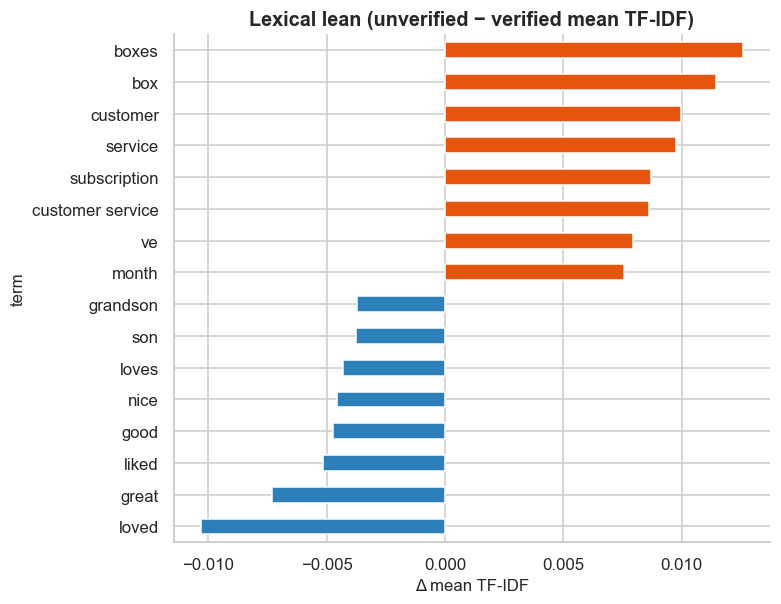

In [4]:
iv = np.where((df["verified_purchase"]==True).to_numpy())[0]
iu = np.where((df["verified_purchase"]==False).to_numpy())[0]
mv = np.asarray(X[iv].mean(axis=0)).ravel(); mu = np.asarray(X[iu].mean(axis=0)).ravel()
diff = pd.Series(mu - mv, index=terms).sort_values()
combined = pd.concat([diff.head(8), diff.tail(8)])
colors = [viz.TRUST_COLORS["verified"] if v < 0 else viz.TRUST_COLORS["unverified"] for v in combined.values]
ax = combined.plot.barh(color=colors, figsize=(7,6))
viz.label_axes(ax, "Lexical lean (unverified − verified mean TF-IDF)", "Δ mean TF-IDF", "term")
viz.savefig(ax, str(FIG/"03_discriminative_terms.png")); plt.show()

## Sentiment (VADER) by proxy label

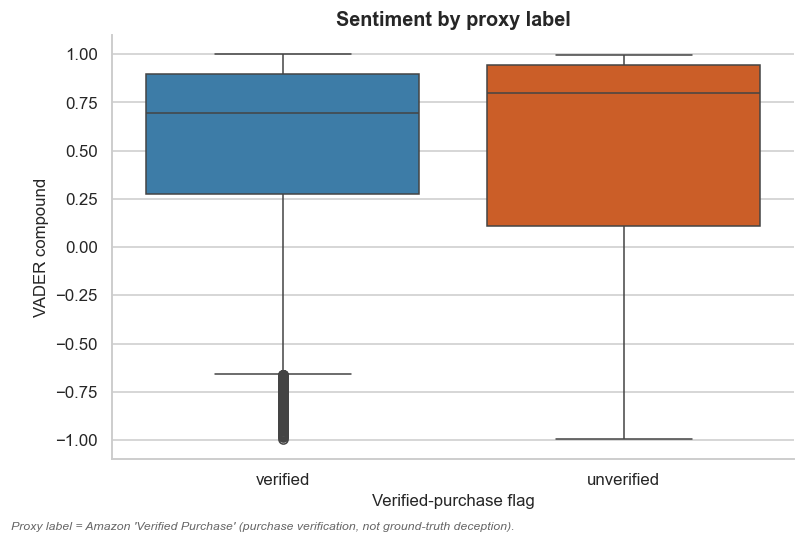

In [5]:
feat = features.add_sentiment(features.add_text_stats(df))
ax = viz.plot_sentiment_by_group(feat); viz.savefig(ax, str(FIG/"03_sentiment.png")); plt.show()

## Behavioral signals (the proxy-strengtheners)
Mean of each behavioral feature, verified vs unverified — these encode *who* reviews and *how*, beyond the text.

In [6]:
feat = features.build_feature_table(df, config)
behav = ["reviewer_review_count","reviewer_category_breadth","product_burst_max",
         "max_intra_product_similarity","helpful_votes_pz","product_rating_skew","word_count"]
g = feat.assign(proxy=feat["verified_purchase"].map({True:"verified",False:"unverified"}))
print(g[g.proxy.notna()].groupby("proxy")[behav].mean().round(3).T.to_string())

2026-06-09 02:57:11,305 | review_deception.features | INFO | Built feature table: 16216 rows × 44 columns.


proxy                         unverified  verified
reviewer_review_count              1.110     1.175
reviewer_category_breadth          1.000     1.000
product_burst_max                 23.176    20.063
max_intra_product_similarity       0.290     0.319
helpful_votes_pz                   0.192    -0.026
product_rating_skew               -0.763    -0.890
word_count                        72.101    43.911


### Which single signals separate the proxy? (univariate AUC)
A preview of notebook 04: each feature's standalone separability of unverified reviews.

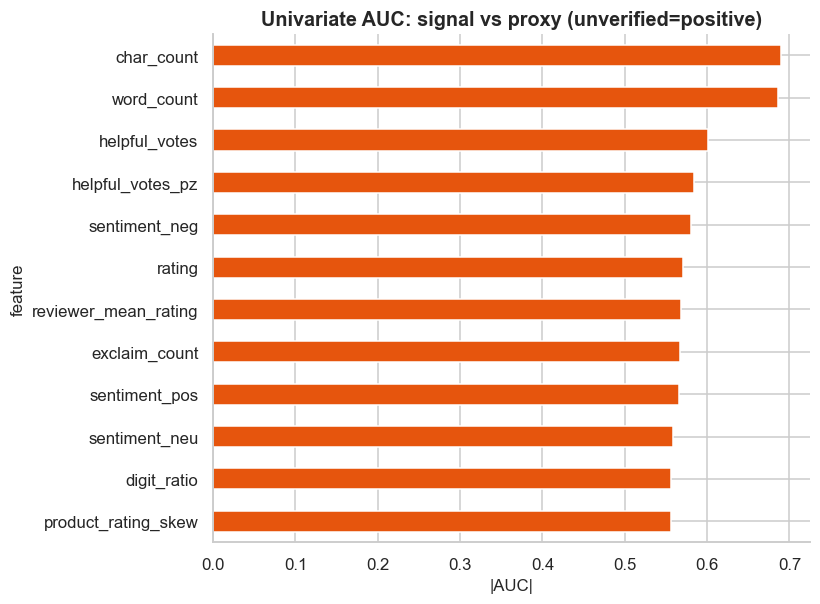

char_count              0.690
word_count              0.686
helpful_votes           0.601
helpful_votes_pz        0.584
sentiment_neg           0.581
rating                  0.570
reviewer_mean_rating    0.569
exclaim_count           0.567
sentiment_pos           0.566
sentiment_neu           0.558
digit_ratio             0.556
product_rating_skew     0.556


In [7]:
from src import models
Xd = models.design_matrix(feat)
auc = models.univariate_feature_auc(Xd, (df["verified_purchase"]==False).astype(int))
top12 = auc.head(12).sort_values()
ax = top12.plot.barh(color=viz.TRUST_COLORS["unverified"], figsize=(7,6))
viz.label_axes(ax, "Univariate AUC: signal vs proxy (unverified=positive)", "|AUC|", "feature")
viz.savefig(ax, str(FIG/"03_feature_auc.png")); plt.show()
print(auc.head(12).round(3).to_string())

**Takeaway.** Text length/effort and a handful of behavioral signals carry most of the separability; notebook 04 turns these into a classifier, and notebook 07 tests which survive a real fake-review label.